# Paso 0: El "Ritual" de Preparación

Siempre preparamos el lienzo y el índice de tiempo antes de empezar.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos los datos y configuramos el DatetimeIndex (Regla de McKinney)
data_casas = (
    pd.read_csv('files_folder/mercado_inmobiliario.csv')
    .assign(fecha_venta = lambda x: pd.to_datetime(x['fecha_venta']))
    .set_index('fecha_venta')
)

print(f"Datos inmobiliarios cargados: {data_casas.shape[0]} propiedades listas para graficar.")

Datos inmobiliarios cargados: 5000 propiedades listas para graficar.


# Ejemplo 1: Gráfico de Líneas (Macroeconomía del Real Estate)

 *El Problema Real:* Los inversores quieren saber si el mercado se está enfriando o calentando. Quieren ver el Volumen Total de Ventas (USD) por mes.
*Teoría Aplicada:* Solo las líneas pueden contar la historia del tiempo. Usaremos .resample('ME') (Month End) para agrupar las ventas de cada mes.

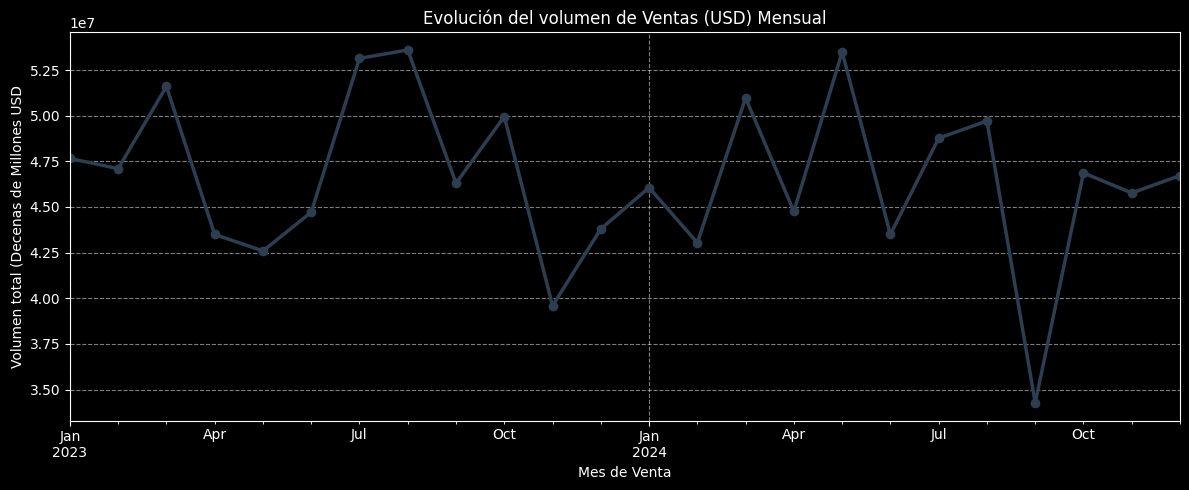

In [28]:
# Pipeline visual: Agrupar por mes -> Sumar -> Graficar
(
    data_casas['precio_usd']
    .resample('ME')
    .sum()
    .plot(
        kind='line',
        figsize=(12,5),
        color = '#2c3e50',   # Azul oscuro corporatico
        linewidth = 2.5,
        marker='o', # Circulos en cada mes para ver el dato exacto
        title = 'Evolución del volumen de Ventas (USD) Mensual'
    )
)

plt.xlabel('Mes de Venta')
plt.ylabel('Volumen total (Decenas de Millones USD')
plt.grid (True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Fíjate cómo el código fluye orgánicamente. No creamos una variable ventas_mensuales, simplemente le dijimos a Pandas: "Toma el precio, agrúpalo por mes, súmalo y dibújalo".

# Ejemplo 2: Gráfico de Barras Horizontales (El Valor del Barrio)

*El Problema Real:* Una agencia quiere enfocar sus esfuerzos de marketing en la zona más rentable. Quieren saber el Precio Promedio de una casa según el barrio.
*Teoría Aplicada:* Comparación de categorías. Como los nombres de los barrios son largos (ej. "Norte (Residencial)"), usamos .plot(kind='barh') para que se lean fácilmente. Además, es obligatorio usar .sort_values() para que el gráfico tenga un orden lógico.

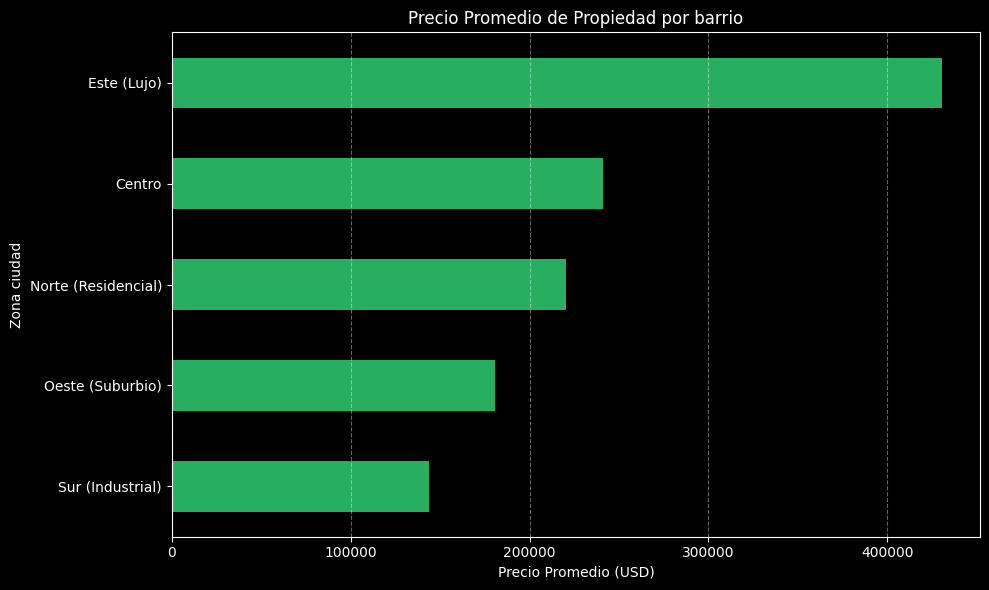

In [29]:
# Pipeline visual: Agrupar por barrio -> Promedio -> Ordenar -> Graficar
(
    data_casas.groupby('barrio')['precio_usd']
    .mean()
    .sort_values()  # Clave: Ordena de menor a mayor para estética visual
    .plot(
        kind='barh',
        figsize=(10,6),
        color ='#27ae60',    # Verde dinero
        title = 'Precio Promedio de Propiedad por barrio'
    )
)
plt.xlabel('Precio Promedio (USD)')
plt.ylabel('Zona ciudad')
plt.grid(axis='x',linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Si ejecutas esto, verás claramente cómo la barra de "Este (Lujo)" aplasta a las demás. Una imagen responde la pregunta de negocio al instante

# Ejemplo 3: Histograma (Descubriendo el "Target" de Clientes)

*El Problema Real:* El banco quiere ofrecer créditos hipotecarios, pero necesita saber en qué rango de precios está la gran mayoría de las casas vendidas. ¿Son todas de un millón de dólares o la mayoría son baratas?
*Teoría Aplicada:* El Histograma revela la distribución estadística. Usaremos bins=40 para dividir todo el rango de precios en 40 "cajones" o categorías.

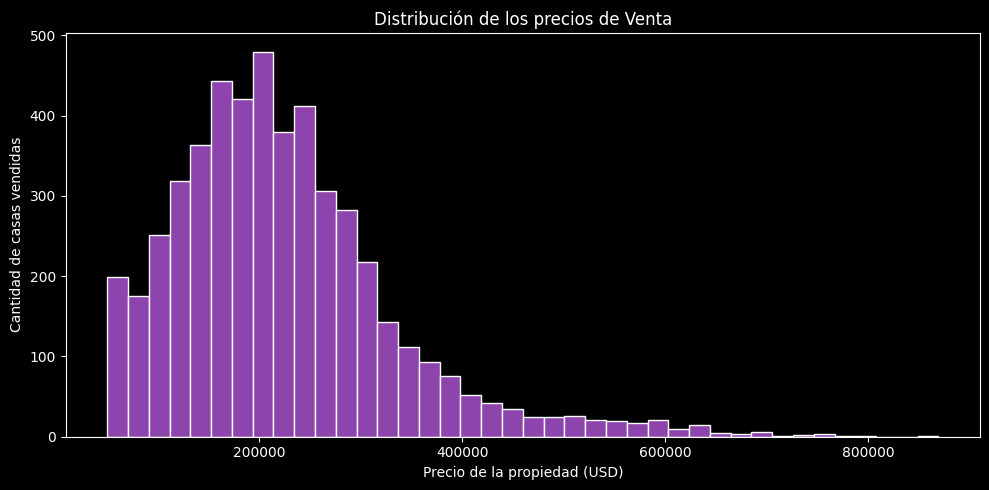

In [30]:
# Pipeline visual: Seleccionar columna -> Graficar distribución
(
    data_casas['precio_usd']
    .plot(
        kind='hist',
        bins=40,    # 40 cajones de precios
        figsize=(10,5),
        color ='#8e44ad',   #Morado
        edgecolor = 'white', # Borde blanco para separar visualmente los cajones
        title ='Distribución de los precios de Venta'
    )
)

plt.xlabel('Precio de la propiedad (USD)')
plt.ylabel('Cantidad de casas vendidas')
plt.tight_layout()
plt.show()

Verás que la gráfica forma una "montaña" ligeramente tirada hacia la izquierda. Esto te indica de inmediato que las casas de lujo (extremo derecho) son anomalías y el grueso del mercado es de clase media.

Ejemplo 4: Gráfico de Dispersión (Validando Hipótesis)

*El Problema Real:* Un cliente afirma: "Mientras más grande es la casa, siempre será más cara". El jefe te pide validar si esto es 100% cierto.
*Teoría Aplicada (McKinney):* Para correlacionar dos variables numéricas masivas (Metros vs. Precio), el Scatter Plot es la ley. Usaremos el parámetro mágico alpha para manejar la sobreposición de miles de puntos.

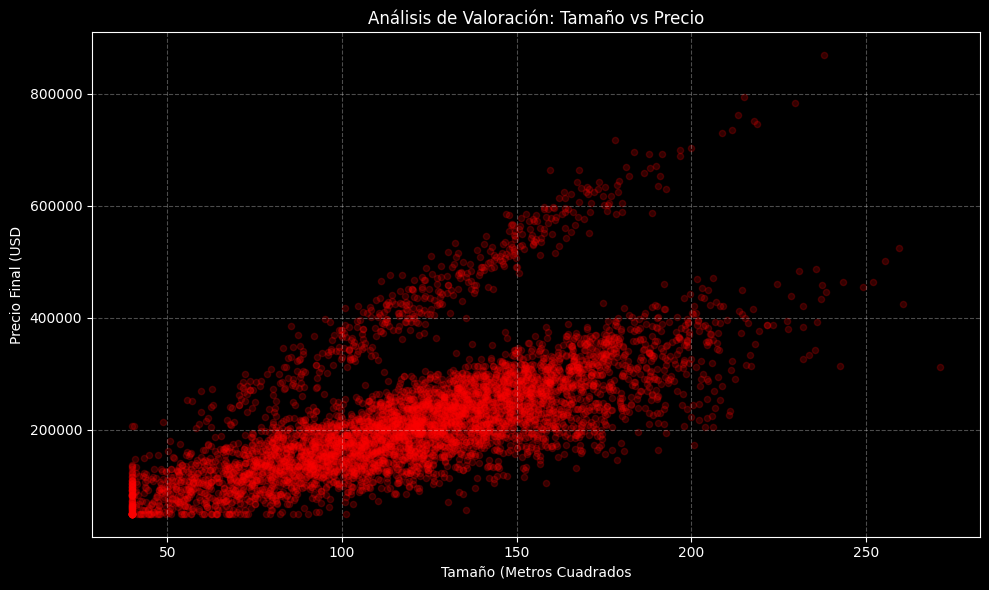

In [31]:
# Pipeline visual: DataFrame -> Scatter Plot
(
    data_casas
    .plot(
        kind='scatter',
        x='metros_cuadrados',
        y='precio_usd',
        figsize=(10,6),
        color ='red',
        alpha = 0.2,    #CLAVE: Transparencia del 20% para revelar densidad
        title ='Análisis de Valoración: Tamaño vs Precio'
    )
)

plt.xlabel('Tamaño (Metros Cuadrados')
plt.ylabel ('Precio Final (USD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Al usar alpha=0.2, los lugares donde hay muchas casas agrupadas se verán de un rojo intenso, y las casas atípicas (como una casa pequeña pero carísima en el barrio de lujo) se verán como puntitos pálidos aislados. Si la nube sube en diagonal, la hipótesis del cliente es correcta.